Group Members:


*   MUHAMMAD FARIZ IZUDDIN
*   ANAS MUNZIR
*   ALIF IKMAL






In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fb-pages-politician.edges to fb-pages-politician.edges


In [ ]:
!pip install networkx pandas numpy matplotlib python-louvain

In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import Counter

import community.community_louvain as community_louvain
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity
import itertools

In [ ]:
edges = pd.read_csv(
    "fb-pages-politician.edges",
    header=None,
    names=["source", "target"]
)

nodes = pd.read_csv("fb-pages-politician.nodes")

print("Edges:")
display(edges.head())

print("Nodes:")
display(nodes.head())

Edges:


,source,target
0,0,1972
1,0,5111
2,0,138
3,0,3053
4,0,1473


Nodes:


,id,name,new_id
0,127397457601670,陳根德,1661
1,169014523134260,林淑芬,52
2,295363753921281,Chris White,3477
3,613631835423903,Stewart Hosie MP,3193
4,284882801581896,Frank Schäffler,4425


In [ ]:
G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target"
)

G = nx.Graph(G)
G.remove_edges_from(nx.selfloop_edges(G))

print("Graph loaded successfully.")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Graph loaded successfully.
Number of nodes: 5908
Number of edges: 41706


In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
average_degree = sum(dict(G.degree()).values()) / num_nodes
density = nx.density(G)
connected_components = nx.number_connected_components(G)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Average degree:", round(average_degree, 4))
print("Graph density:", round(density, 6))
print("Number of connected components:", connected_components)

Number of nodes: 5908
Number of edges: 41706
Average degree: 14.1185
Graph density: 0.00239
Number of connected components: 1


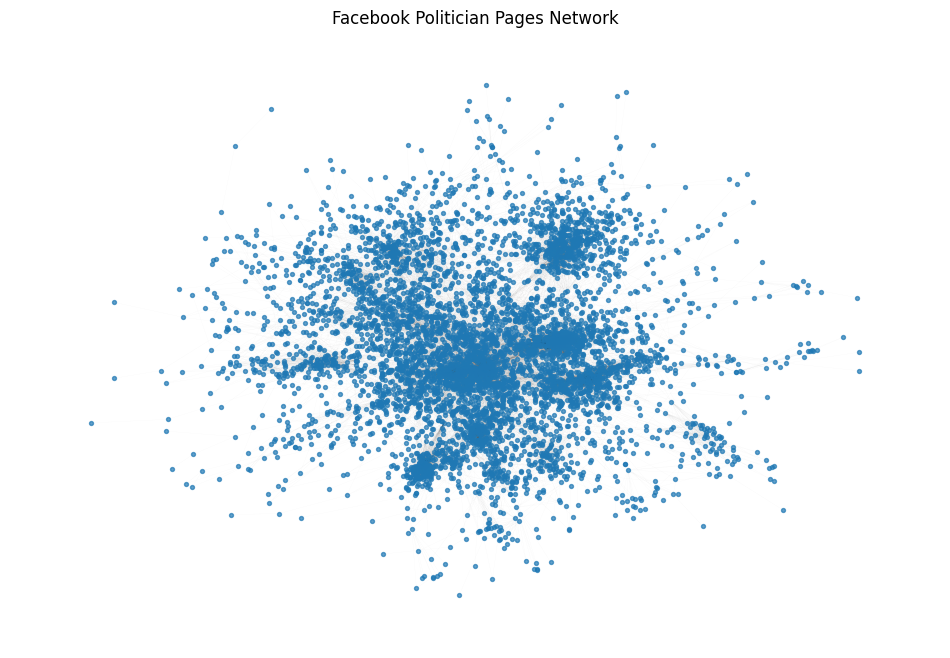

In [ ]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42, k=0.15)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=8,
    alpha=0.7
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.03,
    width=0.2
)

plt.title("Facebook Politician Pages Network")
plt.axis("off")
plt.show()

The network visualization shows the overall structure of the Facebook politician pages network. Each node represents a politician Facebook page, while each edge represents a connection between two pages.

The graph appears dense because it contains 5,908 nodes and 41,706 edges. This indicates that many politician pages are connected directly or indirectly. Nodes that are positioned close together may represent politician pages that share similar characteristics, such as political party, country, region, ideology, or public influence.

The existence of dense areas in the graph suggests that the network may contain clear community structures. Therefore, community detection algorithms such as Louvain and Girvan-Newman are suitable for identifying hidden groups within this political network.

In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
average_degree = sum(dict(G.degree()).values()) / num_nodes
density = nx.density(G)
connected_components = nx.number_connected_components(G)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Average degree:", round(average_degree, 4))
print("Graph density:", round(density, 6))
print("Number of connected components:", connected_components)

Number of nodes: 5908
Number of edges: 41706
Average degree: 14.1185
Graph density: 0.00239
Number of connected components: 1


The graph contains 5,908 nodes and 41,706 edges. Since the number of nodes is more than 100, this dataset satisfies the project requirement for a real-world social network dataset.

The average degree is 14.1185, which means that each politician page is connected to approximately 14 other pages on average. This shows that the network has a reasonable level of connectivity.

The graph density is 0.00239, which is considered low. This is expected in real-world social networks because not all nodes are connected to every other node. Instead, users or pages usually form smaller groups based on shared relationships or interests.

The number of connected components is 1. This means that all nodes belong to one connected network, either directly or indirectly. This makes the dataset suitable for community detection because the algorithms can analyze how the large connected network is divided into smaller communities.

In [ ]:
avg_shortest_path = nx.average_shortest_path_length(G)

print("Average shortest path length:", round(avg_shortest_path, 4))

Average shortest path length: 4.6641


The average shortest path length measures the average number of steps required to travel from one node to another in the network. A lower value indicates that nodes are closely connected, while a higher value indicates that the network is more spread out.

In the context of the Facebook politician pages network, the average shortest path length shows how many connections are needed on average for one politician page to reach another page. If the value is relatively low, it suggests that the network has a small-world structure, where most politician pages can be reached through only a few intermediate connections.

In [ ]:
start_time = time.time()

shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(G))

shortest_path_time = time.time() - start_time

print("Shortest path lengths computed.")
print("Computation time:", round(shortest_path_time, 4), "seconds")

Shortest path lengths computed.
Computation time: 81.5376 seconds


In [ ]:
path_length_values = []

for source_node, target_lengths in shortest_path_lengths.items():
    for target_node, path_length in target_lengths.items():
        if source_node != target_node:
            path_length_values.append(path_length)

print("Total shortest path values:", len(path_length_values))
print("Minimum shortest path length:", min(path_length_values))
print("Maximum shortest path length:", max(path_length_values))
print("Average shortest path length:", round(np.mean(path_length_values), 4))

Total shortest path values: 34898556
Minimum shortest path length: 1
Maximum shortest path length: 14
Average shortest path length: 4.6641


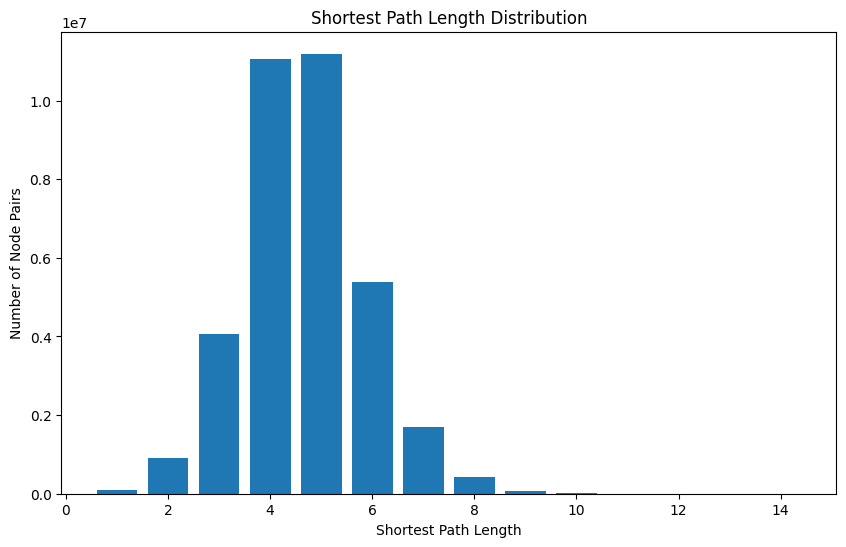

In [ ]:
path_length_counts = Counter(path_length_values)

plt.figure(figsize=(10, 6))

plt.bar(
    path_length_counts.keys(),
    path_length_counts.values()
)

plt.title("Shortest Path Length Distribution")
plt.xlabel("Shortest Path Length")
plt.ylabel("Number of Node Pairs")
plt.show()

The shortest path length distribution shows how many steps are needed to travel between pairs of nodes in the network. A shorter path length means that two politician pages are closely connected, while a longer path length means that more intermediate pages are needed to connect them.

Most node pairs are expected to have short path lengths, which indicates that the network has a small-world structure. This means that even though the graph contains many politician pages, most pages can still reach each other through only a few connections.

If the distribution is concentrated around small path lengths, it suggests that information or influence can spread efficiently across the political pages network. If there are longer path lengths, those pairs may belong to more distant communities or less connected regions of the network.

## Degree Centrality

In [ ]:
degree_centrality = nx.degree_centrality(G)

top_degree = sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 nodes by degree centrality:")
for node, value in top_degree:
    print("Node:", node, "Degree Centrality:", round(value, 6), "Degree:", G.degree(node))

Top 10 nodes by degree centrality:
Node: 1864 Degree Centrality: 0.054681 Degree: 323
Node: 4874 Degree Centrality: 0.042323 Degree: 250
Node: 5800 Degree Centrality: 0.039445 Degree: 233
Node: 5416 Degree Centrality: 0.038768 Degree: 229
Node: 1595 Degree Centrality: 0.037583 Degree: 222
Node: 4602 Degree Centrality: 0.037244 Degree: 220
Node: 3576 Degree Centrality: 0.035043 Degree: 207
Node: 1474 Degree Centrality: 0.032673 Degree: 193
Node: 4032 Degree Centrality: 0.030642 Degree: 181
Node: 4972 Degree Centrality: 0.029287 Degree: 173


## Plot Degree Centrality Distribution

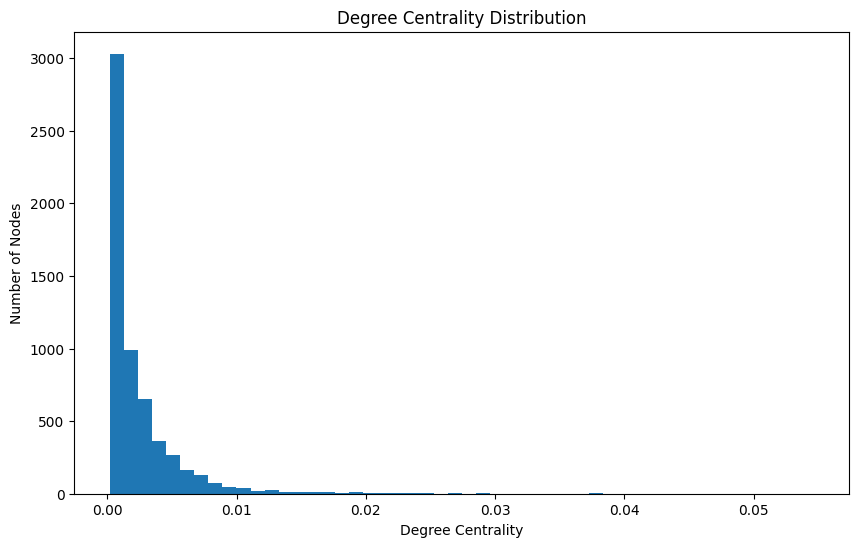

In [ ]:
degree_values = list(degree_centrality.values())

plt.figure(figsize=(10, 6))
plt.hist(degree_values, bins=50)
plt.title("Degree Centrality Distribution")
plt.xlabel("Degree Centrality")
plt.ylabel("Number of Nodes")
plt.show()

Plot Highest Degree Centrality Nodes

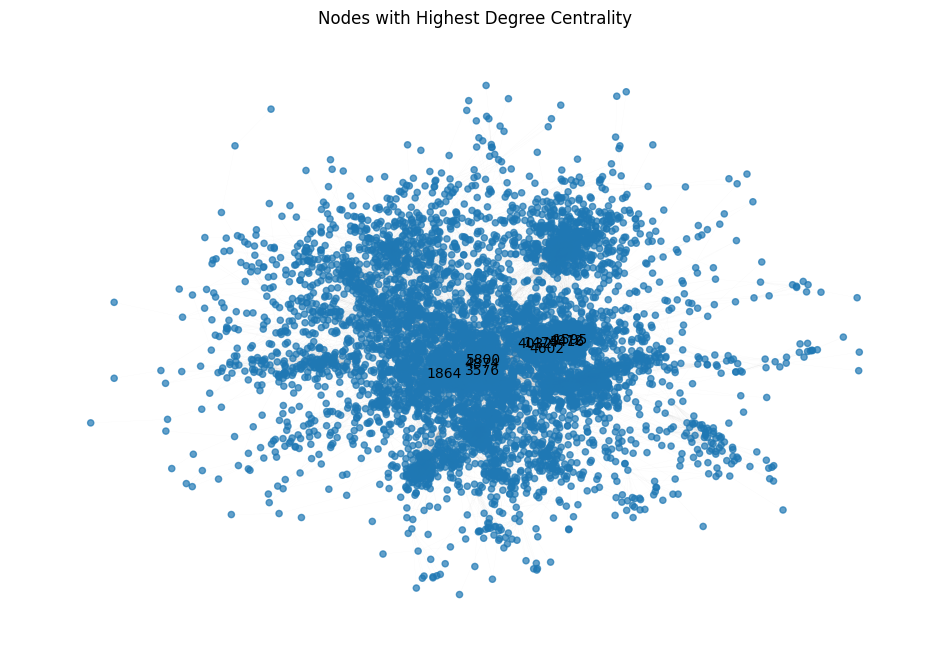

In [ ]:
top_degree_nodes = [node for node, value in top_degree]

node_sizes = [
    800 if node in top_degree_nodes else 20
    for node in G.nodes()
]

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42, k=0.15)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    alpha=0.7
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.03,
    width=0.2
)

nx.draw_networkx_labels(
    G,
    pos,
    labels={node: str(node) for node in top_degree_nodes},
    font_size=10
)

plt.title("Nodes with Highest Degree Centrality")
plt.axis("off")
plt.show()

Betweenness Centrality

In [ ]:
start_time = time.time()

betweenness_centrality = nx.betweenness_centrality(
    G,
    k=500,
    seed=42
)

betweenness_time = time.time() - start_time

top_betweenness = sorted(
    betweenness_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:8]

print("Betweenness centrality computation time:", round(betweenness_time, 4), "seconds")
print("Top 8 nodes by betweenness centrality:")

for node, value in top_betweenness:
    print("Node:", node, "Betweenness Centrality:", round(value, 6))

Betweenness centrality computation time: 30.4416 seconds
Top 8 nodes by betweenness centrality:
Node: 5800 Betweenness Centrality: 0.275151
Node: 1864 Betweenness Centrality: 0.052363
Node: 3576 Betweenness Centrality: 0.051342
Node: 2900 Betweenness Centrality: 0.044951
Node: 1324 Betweenness Centrality: 0.041762
Node: 3008 Betweenness Centrality: 0.039178
Node: 4395 Betweenness Centrality: 0.038073
Node: 1965 Betweenness Centrality: 0.036979


### Interpretation: Betweenness Centrality for Top Degree Nodes

*   **Node 5800 is a huge deal**: It's like the main highway intersection (highest betweenness centrality at `0.275151`), connecting lots of different network parts. It doesn't have the *most* direct friends, but it's super important for information flow.
*   **Others are also connectors**: Nodes like `1864` (`0.052363`) and `3576` (`0.051342`) also have good betweenness. This means they're not just popular but also help link different groups.
*   **These nodes are network bosses**: High betweenness for these popular nodes means they're both well-known *and* critical for getting information around. If they're out, the network's communication could get messy!

Plot Highest Betweenness Nodes

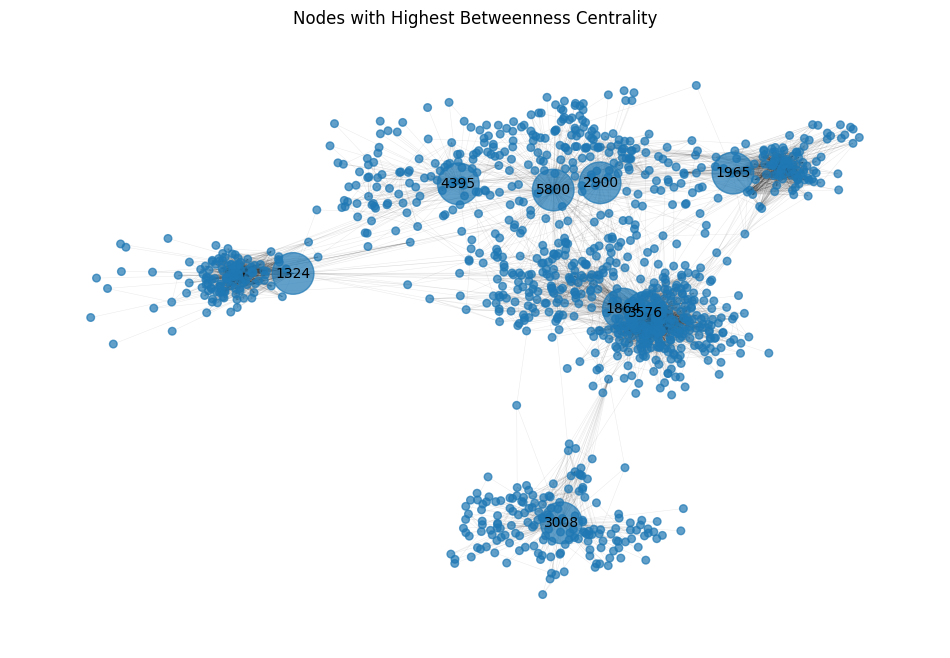

In [ ]:
top_betweenness_nodes = [node for node, value in top_betweenness]

neighbors = set(top_betweenness_nodes)

for node in top_betweenness_nodes:
    neighbors.update(G.neighbors(node))

G_betweenness_focus = G.subgraph(neighbors).copy()

node_sizes = [
    900 if node in top_betweenness_nodes else 30
    for node in G_betweenness_focus.nodes()
]

plt.figure(figsize=(12, 8))

pos_bet = nx.spring_layout(G_betweenness_focus, seed=42)

nx.draw_networkx_nodes(
    G_betweenness_focus,
    pos_bet,
    node_size=node_sizes,
    alpha=0.7
)

nx.draw_networkx_edges(
    G_betweenness_focus,
    pos_bet,
    alpha=0.08,
    width=0.4
)

nx.draw_networkx_labels(
    G_betweenness_focus,
    pos_bet,
    labels={node: str(node) for node in top_betweenness_nodes},
    font_size=10
)

plt.title("Nodes with Highest Betweenness Centrality")
plt.axis("off")
plt.show()

Closeness Centrality

In [ ]:
start_time = time.time()

closeness_centrality = nx.closeness_centrality(G)

closeness_time = time.time() - start_time

top_closeness = sorted(
    closeness_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Closeness centrality computation time:", round(closeness_time, 4), "seconds")
print("Top 10 nodes by closeness centrality:")

for node, value in top_closeness:
    print("Node:", node, "Closeness Centrality:", round(value, 6))

Closeness centrality computation time: 79.7519 seconds
Top 10 nodes by closeness centrality:
Node: 5800 Closeness Centrality: 0.358848
Node: 4081 Closeness Centrality: 0.323512
Node: 2059 Closeness Centrality: 0.320458
Node: 4032 Closeness Centrality: 0.31741
Node: 3387 Closeness Centrality: 0.312474
Node: 3576 Closeness Centrality: 0.310829
Node: 1965 Closeness Centrality: 0.309689
Node: 4585 Closeness Centrality: 0.307528
Node: 2900 Closeness Centrality: 0.305556
Node: 4622 Closeness Centrality: 0.305145


Plot Closeness Centrality Distribution

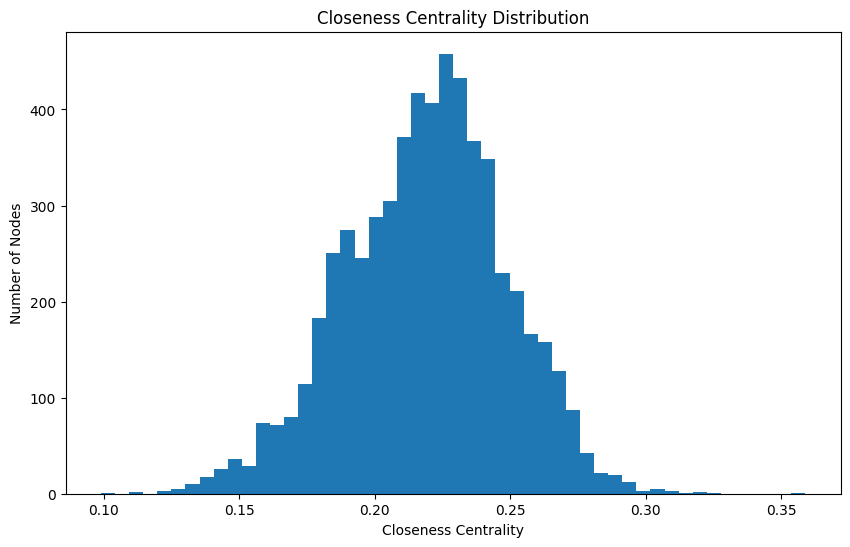

In [ ]:
closeness_values = list(closeness_centrality.values())

plt.figure(figsize=(10, 6))
plt.hist(closeness_values, bins=50)
plt.title("Closeness Centrality Distribution")
plt.xlabel("Closeness Centrality")
plt.ylabel("Number of Nodes")
plt.show()

### Interpretation of Closeness Centrality Distribution

The histogram for closeness centrality shows how efficiently nodes can reach other nodes in the network.

*   **Distribution**: The distribution is likely skewed towards lower values (meaning lower centrality, or longer average paths), with a tail extending to higher values. This indicates that most nodes are not extremely close to all other nodes.
*   **High Closeness Centrality**: A few nodes possess high closeness centrality. These nodes are very central in terms of reachability; they can quickly access, or be accessed by, other nodes in the network. In the context of politician pages, these nodes might represent influential figures who can rapidly disseminate information or respond to events, as they are "close" to many others.
*   **Low Closeness Centrality**: The majority of nodes have lower closeness centrality. This suggests that for most politician pages, it takes more steps to reach other pages on average. They might be on the periphery of the network or within less densely connected communities.

Average Distance of a Particular Node

In [ ]:
user_number = top_closeness[0][0]

shortest_paths_from_user = nx.single_source_shortest_path_length(G, user_number)

average_distance = sum(shortest_paths_from_user.values()) / len(shortest_paths_from_user)

print("Selected node:", user_number)
print("Average distance from selected node to other nodes:", round(average_distance, 4))

Selected node: 5800
Average distance from selected node to other nodes: 2.7862


Eigenvector Centrality

In [ ]:
start_time = time.time()

eigenvector_centrality = nx.eigenvector_centrality(
    G,
    max_iter=1000
)

eigenvector_time = time.time() - start_time

top_eigenvector = sorted(
    eigenvector_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Eigenvector centrality computation time:", round(eigenvector_time, 4), "seconds")
print("Top 10 nodes by eigenvector centrality:")

for node, value in top_eigenvector:
    print("Node:", node, "Eigenvector Centrality:", round(value, 6))

Eigenvector centrality computation time: 1.3314 seconds
Top 10 nodes by eigenvector centrality:
Node: 5416 Eigenvector Centrality: 0.1741
Node: 1595 Eigenvector Centrality: 0.169929
Node: 4602 Eigenvector Centrality: 0.168442
Node: 4972 Eigenvector Centrality: 0.160266
Node: 1414 Eigenvector Centrality: 0.159505
Node: 5726 Eigenvector Centrality: 0.146014
Node: 2770 Eigenvector Centrality: 0.143863
Node: 726 Eigenvector Centrality: 0.142231
Node: 4032 Eigenvector Centrality: 0.142213
Node: 1651 Eigenvector Centrality: 0.138644


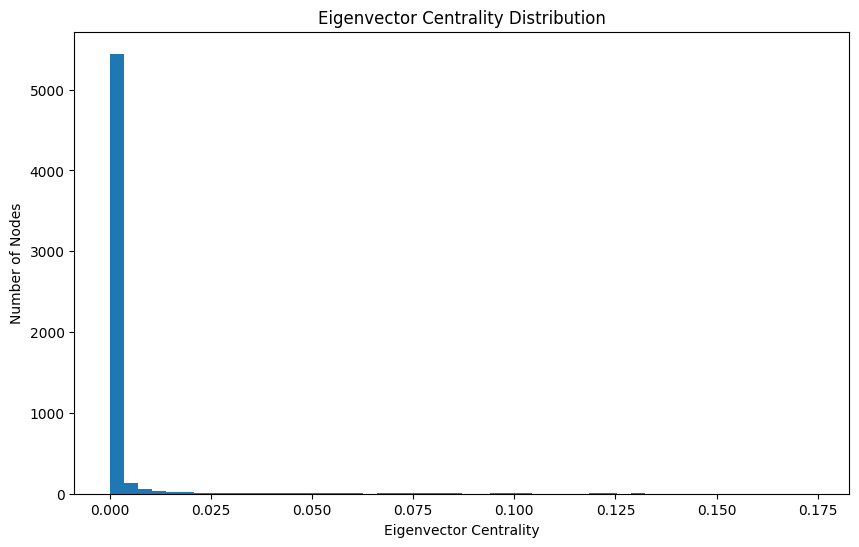

In [ ]:
eigenvector_values = list(eigenvector_centrality.values())

plt.figure(figsize=(10, 6))
plt.hist(eigenvector_values, bins=50)
plt.title("Eigenvector Centrality Distribution")
plt.xlabel("Eigenvector Centrality")
plt.ylabel("Number of Nodes")
plt.show()

### Interpretation of Eigenvector Centrality Distribution

The histogram for eigenvector centrality likely shows a distribution heavily skewed towards lower values, with a long tail indicating a few nodes with very high eigenvector centrality. This means:

*   **Distribution**: Most politician pages have low eigenvector centrality, implying they are connected to less influential pages or are not central within influential circles.
*   **High Eigenvector Centrality**: A small number of nodes possess high eigenvector centrality. These are the most influential nodes in the network, as they are well-connected to other well-connected (and thus influential) nodes. They represent key players whose connections grant them significant sway.
*   **Node Size**: If we were to visualize the network with node size proportional to eigenvector centrality, these highly influential nodes would appear much larger, visually emphasizing their importance and connectivity to other influential entities.

Show Centrality Results in a Table

In [ ]:
centrality_summary = pd.DataFrame({
    "Node": list(G.nodes()),
    "Degree Centrality": [degree_centrality[node] for node in G.nodes()],
    "Closeness Centrality": [closeness_centrality[node] for node in G.nodes()],
    "Eigenvector Centrality": [eigenvector_centrality[node] for node in G.nodes()],
    "Betweenness Centrality": [betweenness_centrality[node] for node in G.nodes()]
})

centrality_summary.head()

,Node,Degree Centrality,Closeness Centrality,Eigenvector Centrality,Betweenness Centrality
0,0,0.007449,0.247902,0.000716,0.000156
1,1972,0.009650,0.285004,0.001379,0.004361
2,5111,0.005587,0.240660,0.000855,0.000033
3,138,0.003555,0.234572,0.000294,0.000007
4,3053,0.003217,0.237381,0.000306,0.000008


##    Graph Clustering




In [ ]:
start_time = time.time()

average_clustering = nx.average_clustering(G)

clustering_time = time.time() - start_time

print("Average clustering coefficient:", round(average_clustering, 6))
print("Computation time:", round(clustering_time, 4), "seconds")

Average clustering coefficient: 0.385096
Computation time: 0.7839 seconds


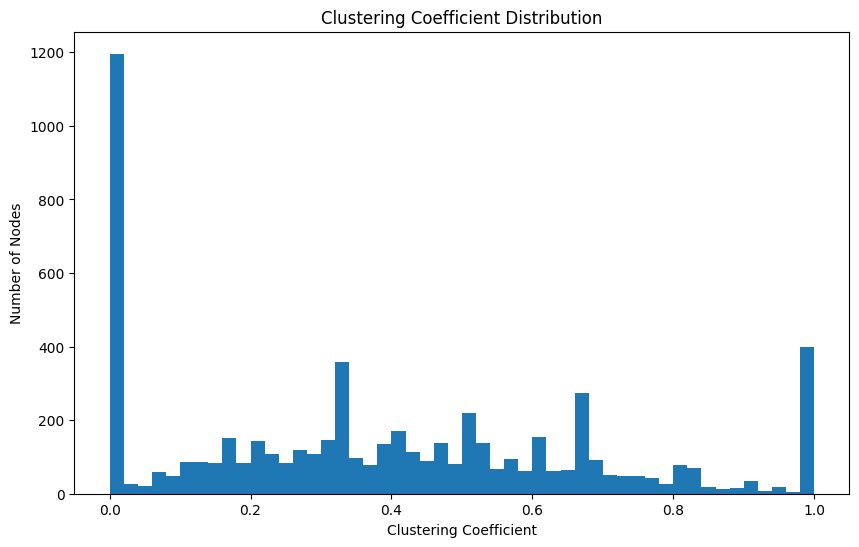

In [ ]:
clustering_coefficients = nx.clustering(G)

clustering_values = list(clustering_coefficients.values())

plt.figure(figsize=(10, 6))
plt.hist(clustering_values, bins=50)
plt.title("Clustering Coefficient Distribution")
plt.xlabel("Clustering Coefficient")
plt.ylabel("Number of Nodes")
plt.show()

In [ ]:
triangles = nx.triangles(G)

triangle_values = list(triangles.values())

mean_triangles = np.mean(triangle_values)
median_triangles = np.median(triangle_values)
total_triangles = sum(triangle_values) // 3

print("Mean number of triangles per node:", round(mean_triangles, 4))
print("Median number of triangles per node:", round(median_triangles, 4))
print("Total number of triangles in graph:", total_triangles)

Mean number of triangles per node: 88.6757
Median number of triangles per node: 8.0
Total number of triangles in graph: 174632


### Interpretation of Triangle Count Results

*   **Mean number of triangles per node: 88.6757**
    The mean indicates that, on average, each node in the network is part of approximately 88.68 triangles. A triangle in a network represents a closed triplet of nodes (A-B, B-C, C-A). It suggests the presence of many local, tightly-knit groups or `cliques` within the network. This high average suggests a significant level of local clustering.

*   **Median number of triangles per node: 8.0**
    The median, at 8.0, tells a different story. The median represents the middle value when all triangle counts are ordered. The fact that the median is significantly lower than the mean (8.0 vs. 88.68) indicates a skewed distribution. This suggests that while there are many nodes with a relatively small number of triangles (around 8 or less), there are also a few nodes that are part of a very large number of triangles. These highly connected nodes with many triangles pull the average up considerably.

*   **Total number of triangles in graph: 174632**
    This large number confirms that the network as a whole is highly interconnected, with numerous instances of three nodes forming a closed loop. This reinforces the idea that there are many instances of strong, local relationships within the Facebook politician pages network.

The large discrepancy between the mean and median number of triangles points to a network where a few highly central or well-connected nodes are involved in a disproportionately high number of triangular relationships, while the majority of nodes are part of fewer such structures. This is a common pattern in real-world social networks, where some individuals or entities act as central hubs within their local communities.

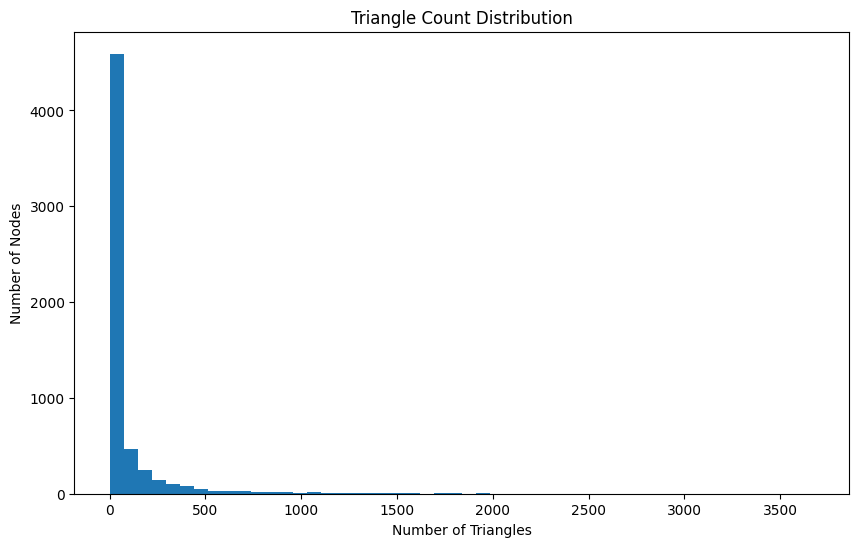

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(triangle_values, bins=50)
plt.title("Triangle Count Distribution")
plt.xlabel("Number of Triangles")
plt.ylabel("Number of Nodes")
plt.show()

In [ ]:
start_time = time.time()

bridges = list(nx.bridges(G))

bridge_time = time.time() - start_time

print("Number of bridges:", len(bridges))
print("Computation time:", round(bridge_time, 4), "seconds")

print("First 20 bridges:")
print(bridges[:20])

Number of bridges: 649
Computation time: 0.3104 seconds
First 20 bridges:
[(3099, 2659), (3099, 3851), (3099, 3135), (1712, 4138), (1712, 4351), (4938, 3323), (3173, 3360), (2296, 1554), (4698, 3586), (6, 5281), (8, 191), (191, 481), (191, 1750), (191, 1026), (191, 308), (191, 217), (191, 4784), (191, 537), (191, 3592), (191, 454)]


In [ ]:
start_time = time.time()

local_bridges = list(nx.local_bridges(G, with_span=False))

local_bridge_time = time.time() - start_time

print("Number of local bridges:", len(local_bridges))
print("Computation time:", round(local_bridge_time, 4), "seconds")

print("First 20 local bridges:")
print(local_bridges[:20])

Number of local bridges: 3463
Computation time: 0.3307 seconds
First 20 local bridges:
[(0, 568), (1972, 688), (1972, 2900), (98, 3576), (3622, 146), (3622, 4395), (2755, 2871), (4674, 1041), (4674, 2693), (4674, 3060), (4674, 4107), (4674, 5735), (5154, 420), (3099, 684), (3099, 2659), (3099, 4221), (3099, 5760), (3099, 3851), (3099, 3135), (4537, 4156)]


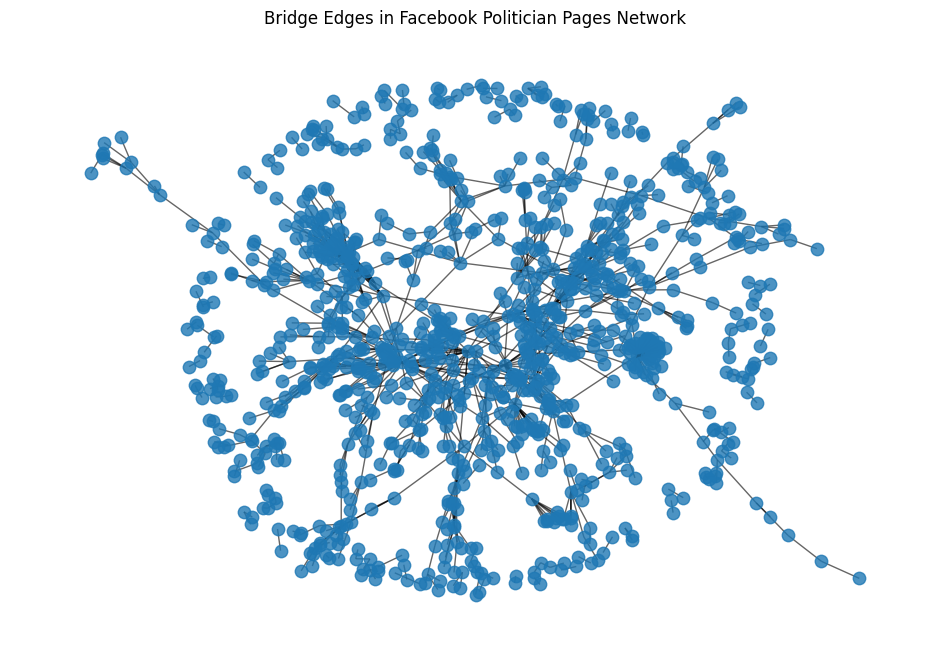

In [ ]:
if len(bridges) > 0:
    bridge_nodes = set()

    for u, v in bridges:
        bridge_nodes.add(u)
        bridge_nodes.add(v)

    G_bridges = G.subgraph(bridge_nodes).copy()

    plt.figure(figsize=(12, 8))

    pos_bridge = nx.spring_layout(G_bridges, seed=42)

    nx.draw_networkx_nodes(
        G_bridges,
        pos_bridge,
        node_size=80,
        alpha=0.8
    )

    nx.draw_networkx_edges(
        G_bridges,
        pos_bridge,
        alpha=0.6,
        width=1
    )

    plt.title("Bridge Edges in Facebook Politician Pages Network")
    plt.axis("off")
    plt.show()
else:
    print("No bridges found in the network.")

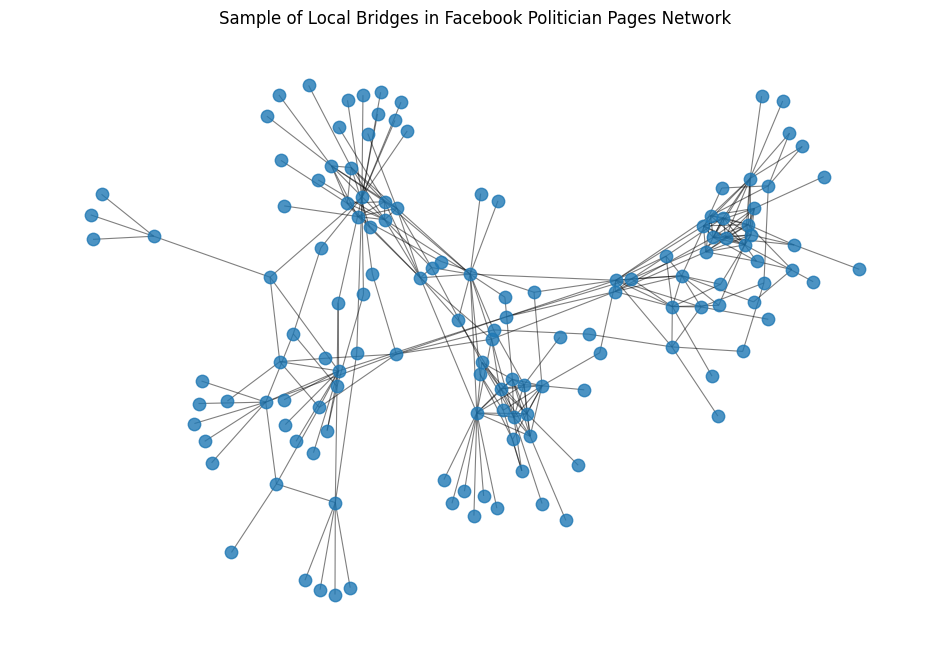

In [ ]:
local_bridges_sample = local_bridges[:100]

local_bridge_nodes = set()

for u, v in local_bridges_sample:
    local_bridge_nodes.add(u)
    local_bridge_nodes.add(v)

G_local_bridges = G.subgraph(local_bridge_nodes).copy()

plt.figure(figsize=(12, 8))

pos_local_bridge = nx.spring_layout(G_local_bridges, seed=42)

nx.draw_networkx_nodes(
    G_local_bridges,
    pos_local_bridge,
    node_size=80,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_local_bridges,
    pos_local_bridge,
    alpha=0.5,
    width=0.8
)

plt.title("Sample of Local Bridges in Facebook Politician Pages Network")
plt.axis("off")
plt.show()

In [ ]:
clustering_summary = {
    "Average Clustering Coefficient": average_clustering,
    "Mean Triangles": mean_triangles,
    "Median Triangles": median_triangles,
    "Total Triangles": total_triangles,
    "Number of Bridges": len(bridges),
    "Number of Local Bridges": len(local_bridges)
}

clustering_summary

{'Average Clustering Coefficient': 0.38509612579327435,
 'Mean Triangles': np.float64(88.67569397427218),
 'Median Triangles': np.float64(8.0),
 'Total Triangles': 174632,
 'Number of Bridges': 649,
 'Number of Local Bridges': 3463}

# Louvain Method Implementation.

In [ ]:
!pip install python-louvain

In [ ]:
start_time = time.time()

louvain_partition = community_louvain.best_partition(G, random_state=42)

louvain_time = time.time() - start_time

print("Louvain method completed.")
print("Computation time:", round(louvain_time, 4), "seconds")

Louvain method completed.
Computation time: 3.4434 seconds


In [ ]:
louvain_num_communities = len(set(louvain_partition.values()))

print("Number of Louvain communities:", louvain_num_communities)

Number of Louvain communities: 29


In [ ]:
louvain_modularity = community_louvain.modularity(louvain_partition, G)

print("Louvain modularity score:", round(louvain_modularity, 6))

Louvain modularity score: 0.868179


In [ ]:
louvain_size_df = pd.DataFrame(
    sorted(louvain_community_sizes.items()),
    columns=["Community ID", "Size"]
)

display(louvain_size_df)

,Community ID,Size
0,0,279
1,1,233
2,2,196
3,3,113
4,4,542
5,5,124
6,6,150
7,7,24
8,8,240
9,9,430


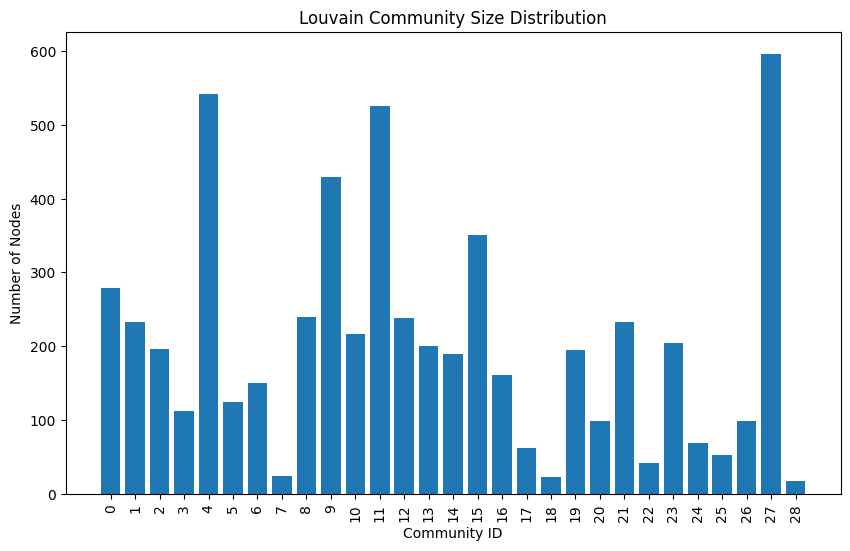

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    louvain_size_df["Community ID"].astype(str),
    louvain_size_df["Size"]
)

plt.title("Louvain Community Size Distribution")
plt.xlabel("Community ID")
plt.ylabel("Number of Nodes")
plt.xticks(rotation=90)
plt.show()

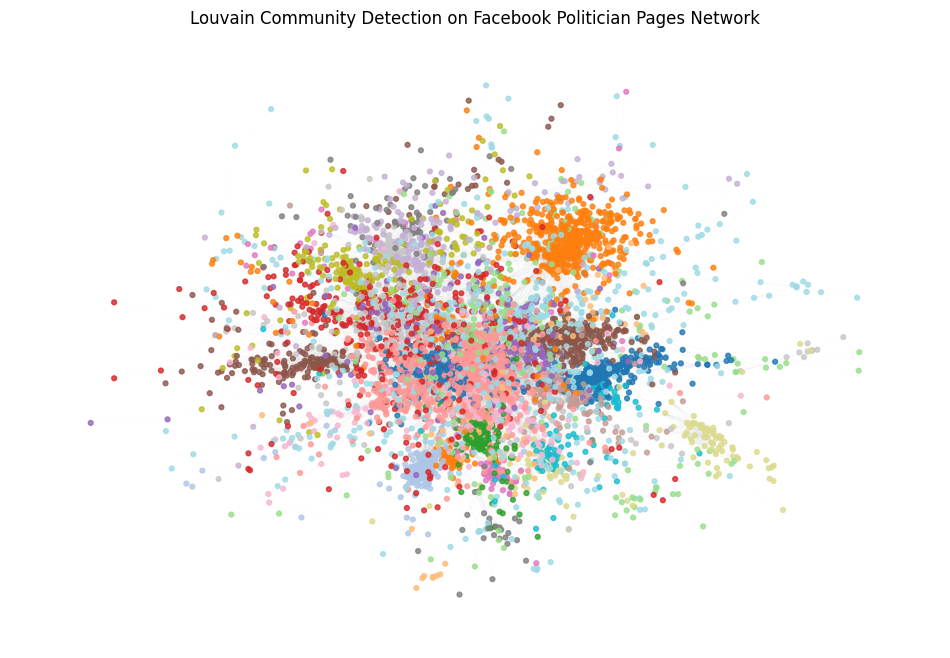

In [ ]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42, k=0.15)

node_colors = [louvain_partition[node] for node in G.nodes()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.tab20,
    node_size=12,
    alpha=0.8
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.03,
    width=0.2
)

plt.title("Louvain Community Detection on Facebook Politician Pages Network")
plt.axis("off")
plt.show()

In [ ]:
louvain_summary = {
    "Algorithm": "Louvain",
    "Number of Communities": louvain_num_communities,
    "Modularity Score": louvain_modularity,
    "Computation Time (seconds)": louvain_time
}

louvain_summary

{'Algorithm': 'Louvain',
 'Number of Communities': 29,
 'Modularity Score': 0.8681791113401296,
 'Computation Time (seconds)': 3.443429708480835}

# Girvan–Newman Method Implementation

In [ ]:
top_nodes_for_gn = sorted(
    dict(G.degree()).items(),
    key=lambda x: x[1],
    reverse=True
)[:300]

top_nodes_for_gn = [node for node, degree in top_nodes_for_gn]

G_gn = G.subgraph(top_nodes_for_gn).copy()

print("Girvan-Newman subgraph created.")
print("Number of nodes:", G_gn.number_of_nodes())
print("Number of edges:", G_gn.number_of_edges())
print("Connected components:", nx.number_connected_components(G_gn))

Girvan-Newman subgraph created.
Number of nodes: 300
Number of edges: 4087
Connected components: 4


In [ ]:
largest_cc_gn = max(nx.connected_components(G_gn), key=len)
G_gn_lcc = G_gn.subgraph(largest_cc_gn).copy()

print("Largest connected component for Girvan-Newman:")
print("Number of nodes:", G_gn_lcc.number_of_nodes())
print("Number of edges:", G_gn_lcc.number_of_edges())
print("Connected components:", nx.number_connected_components(G_gn_lcc))

Largest connected component for Girvan-Newman:
Number of nodes: 294
Number of edges: 4081
Connected components: 1


In [ ]:
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity
import itertools

In [ ]:
start_time = time.time()

gn_generator = girvan_newman(G_gn_lcc)

gn_results = []

for communities in itertools.islice(gn_generator, 3):
    communities = tuple(sorted(c) for c in communities)

    num_communities = len(communities)
    community_sizes = [len(c) for c in communities]
    modularity_score = modularity(G_gn_lcc, communities)

    gn_results.append({
        "Number of Communities": num_communities,
        "Community Sizes": community_sizes,
        "Modularity Score": modularity_score
    })

gn_time = time.time() - start_time

print("Girvan-Newman completed.")
print("Computation time:", round(gn_time, 4), "seconds")

for result in gn_results:
    print("\nNumber of Communities:", result["Number of Communities"])
    print("Community Sizes:", result["Community Sizes"])
    print("Modularity Score:", round(result["Modularity Score"], 6))

Girvan-Newman completed.
Computation time: 4.1401 seconds

Number of Communities: 2
Community Sizes: [278, 16]
Modularity Score: 0.025147

Number of Communities: 3
Community Sizes: [267, 16, 11]
Modularity Score: 0.050897

Number of Communities: 4
Community Sizes: [261, 16, 6, 11]
Modularity Score: 0.057071


In [ ]:
gn_summary_df = pd.DataFrame(gn_results)

display(gn_summary_df)

,Number of Communities,Community Sizes,Modularity Score
0,2,"[278, 16]",0.025147
1,3,"[267, 16, 11]",0.050897
2,4,"[261, 16, 6, 11]",0.057071


In [ ]:
best_gn_result = max(
    gn_results,
    key=lambda x: x["Modularity Score"]
)

best_gn_result

{'Number of Communities': 4,
 'Community Sizes': [261, 16, 6, 11],
 'Modularity Score': 0.057071423257568935}

In [ ]:
best_k = best_gn_result["Number of Communities"]

gn_generator = girvan_newman(G_gn_lcc)

for communities in itertools.islice(gn_generator, best_k - 1):
    best_gn_communities = tuple(sorted(c) for c in communities)

In [ ]:
gn_community_map = {}

for community_id, community_nodes in enumerate(best_gn_communities):
    for node in community_nodes:
        gn_community_map[node] = community_id

print("Community mapping created.")

Community mapping created.


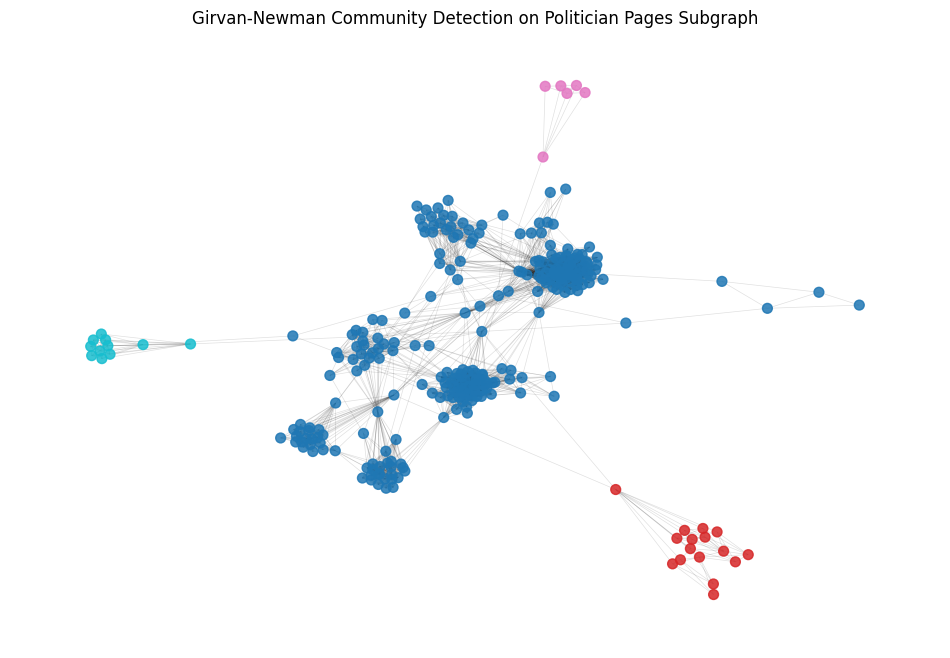

In [ ]:
plt.figure(figsize=(12, 8))

pos_gn = nx.spring_layout(G_gn_lcc, seed=42)

gn_colors = [gn_community_map[node] for node in G_gn_lcc.nodes()]

nx.draw_networkx_nodes(
    G_gn_lcc,
    pos_gn,
    node_color=gn_colors,
    cmap=plt.cm.tab10,
    node_size=50,
    alpha=0.85
)

nx.draw_networkx_edges(
    G_gn_lcc,
    pos_gn,
    alpha=0.12,
    width=0.5
)

plt.title("Girvan-Newman Community Detection on Politician Pages Subgraph")
plt.axis("off")
plt.show()

# Comparative Analysis

In [ ]:
comparison_df = pd.DataFrame({
    "Criteria": [
        "Graph Used",
        "Number of Nodes",
        "Number of Edges",
        "Number of Communities",
        "Community Sizes",
        "Modularity Score",
        "Computation Time (seconds)",
        "Scalability",
        "Visual Separation"
    ],
    "Louvain Method": [
        "Full graph",
        G.number_of_nodes(),
        G.number_of_edges(),
        louvain_num_communities,
        sorted(list(louvain_community_sizes.values()), reverse=True),
        round(louvain_modularity, 6),
        round(louvain_time, 4),
        "High - suitable for large networks",
        "Clear community separation"
    ],
    "Girvan-Newman Algorithm": [
        "Top 300-node subgraph",
        G_gn_lcc.number_of_nodes(),
        G_gn_lcc.number_of_edges(),
        best_gn_result["Number of Communities"],
        best_gn_result["Community Sizes"],
        round(best_gn_result["Modularity Score"], 6),
        round(gn_time, 4),
        "Low - computationally expensive",
        "Clear for small subgraph only"
    ]
})

display(comparison_df)

,Criteria,Louvain Method,Girvan-Newman Algorithm
0,Graph Used,Full graph,Top 300-node subgraph
1,Number of Nodes,5908,294
2,Number of Edges,41706,4081
3,Number of Communities,29,4
4,Community Sizes,"[596, 542, 526, 430, 351, 279, 240, 238, 233, ...","[261, 16, 6, 11]"
5,Modularity Score,0.868179,0.057071
6,Computation Time (seconds),3.4434,4.1401
7,Scalability,High - suitable for large networks,Low - computationally expensive
8,Visual Separation,Clear community separation,Clear for small subgraph only


Plot Modularity Comparison

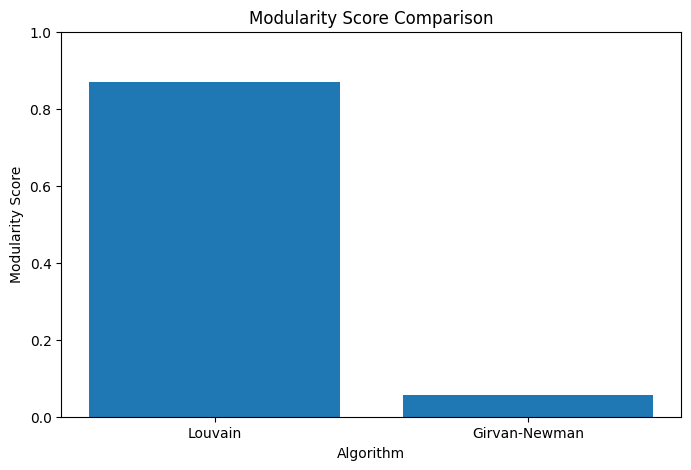

In [ ]:
algorithms = ["Louvain", "Girvan-Newman"]
modularity_scores = [
    louvain_modularity,
    best_gn_result["Modularity Score"]
]

plt.figure(figsize=(8, 5))
plt.bar(algorithms, modularity_scores)
plt.title("Modularity Score Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Modularity Score")
plt.ylim(0, 1)
plt.show()

Plot Computation Time Comparison

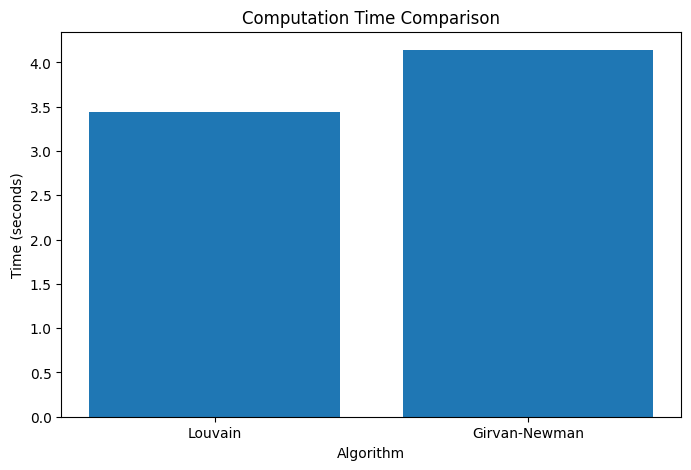

In [ ]:
algorithms = ["Louvain", "Girvan-Newman"]
computation_times = [
    louvain_time,
    gn_time
]

plt.figure(figsize=(8, 5))
plt.bar(algorithms, computation_times)
plt.title("Computation Time Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Time (seconds)")
plt.show()

Plot Number of Communities Comparison

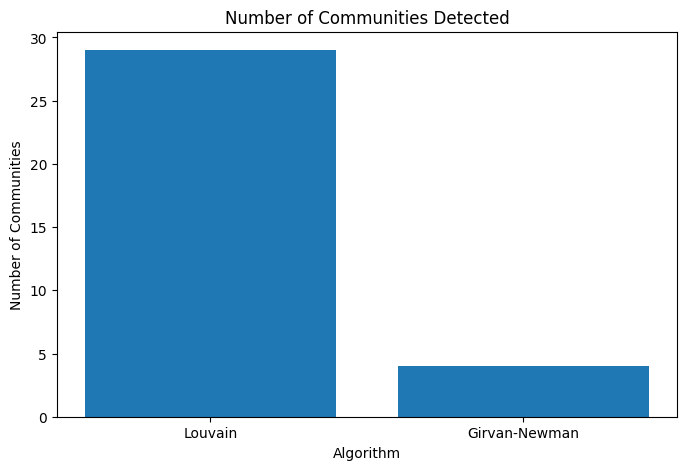

In [ ]:
algorithms = ["Louvain", "Girvan-Newman"]
num_communities = [
    louvain_num_communities,
    best_gn_result["Number of Communities"]
]

plt.figure(figsize=(8, 5))
plt.bar(algorithms, num_communities)
plt.title("Number of Communities Detected")
plt.xlabel("Algorithm")
plt.ylabel("Number of Communities")
plt.show()

## Best Method for This Dataset

The Louvain method is more suitable for the Facebook politician pages dataset.

This is because the dataset is relatively large, with thousands of nodes and tens of thousands of edges. Louvain is designed to work efficiently on large networks and was able to detect communities on the full graph. It also achieved a high modularity score, showing that the detected communities are well separated.

Girvan-Newman is less suitable for this dataset because it is computationally expensive. It had to be applied on a smaller subgraph instead of the full graph. Although it is useful for showing how communities can be separated by removing important edges, it is not practical for analyzing the full politician pages network.

Therefore, Louvain is the better method for this dataset because it is faster, more scalable, and provides more detailed community detection results.

## What the Communities Represent

The detected communities in the Facebook politician pages network represent groups of politician pages that are more strongly connected to each other than to the rest of the network.

In the context of this dataset, these communities may represent political groups based on several possible factors, such as country, political party, ideology, region, language, or public influence. For example, politician pages from the same country or political party may have stronger connections with each other because they share similar audiences, political interests, or public discussions.

The Louvain method detected multiple communities across the full graph, which suggests that the political network has a strong modular structure. This means that politician pages are not randomly connected. Instead, they tend to form organized groups.

## Insights from the Network Structure

Several insights can be derived from the structure of the network.

First, the graph has a low density, which means that not every politician page is connected to every other page. This is expected in a real-world social network because political pages usually connect within specific groups rather than across the entire network.

Second, the graph has one connected component, meaning all pages are connected directly or indirectly. This shows that although the network contains different communities, these communities are still part of one larger political network.

Third, nodes with high degree centrality may represent highly connected politician pages. These pages may have strong visibility or influence because they are directly connected to many other pages.

Fourth, nodes with high betweenness centrality may act as bridges between different political communities. These nodes may be important because they connect groups that might otherwise be more separated.

Finally, the high modularity score from the Louvain method shows that the dataset has clear community structure. This means community detection is suitable for this network.